# Regression with RandomForest


In [1]:
import shap
import pandas as pd
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set(color_codes=True, rc={'figure.figsize': (10, 8)})


## Load, clean, scale, split and train

Load and clean

In [2]:
# Load dataset
data = pd.read_csv('data/bcn_noise_regre_ml_dataset.csv')
# Select the (independant) features that we are going to use to train the model
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night']) # keep only features

Standard Scaling

In [3]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns) #preserve the column names after scaling

In [4]:
# Define the dependant variable / target to predict
y_reg = data.noise_day

Split

In [5]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

Train with RandomForest

In [6]:

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    random_state=42,
    max_depth=None,         
    min_samples_leaf=1,    
    min_samples_split=2,   
)

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accuracy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9581112992651819
0.7037696691912814


ExAI

In [7]:
# Use k-means to summarise background dataset for KernelExplainer
background = shap.kmeans(X_train, 50)  # 50 clusters

# Create KernelExplainer with summarized background
explainer = shap.KernelExplainer(model.predict, background)

shap_values = explainer.shap_values(X_train.iloc[:100, :])

c:\Users\cutro\miniconda3\envs\data_encoding\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


  0%|          | 0/100 [00:00<?, ?it/s]

Summary pot (dot style)

What the Plot Shows
Y-axis: Features, ordered from most to least important (based on mean absolute SHAP values).

Each dot: A single data point’s SHAP value for that feature.

X-axis: SHAP value — the contribution of that feature to pushing the prediction higher (positive) or lower (negative).

Colour of each dot: The original feature value (e.g., blue for low values, red for high values).

How to Interpret It
A dot far to the right means the feature strongly pushes the prediction higher for that sample.

A dot far to the left means the feature strongly pushes the prediction lower.

Colour gradients show how feature value relates to its effect:

If red dots are mostly right, high values increase predictions.

If red dots are mostly left, high values decrease predictions.

The vertical spread of dots per feature shows variation in effect across samples.

Overlapping dots form dense regions, indicating many similar SHAP values.

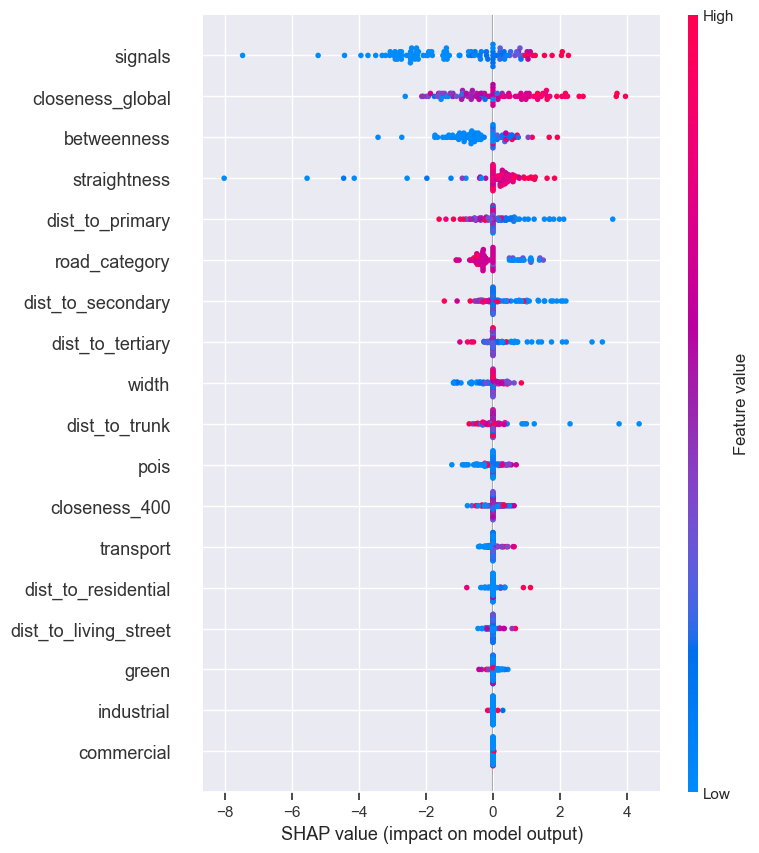

In [8]:

# Summary plot
shap.summary_plot(shap_values, X_train.iloc[:100, :], plot_type="dot")


  0%|          | 0/1 [00:00<?, ?it/s]

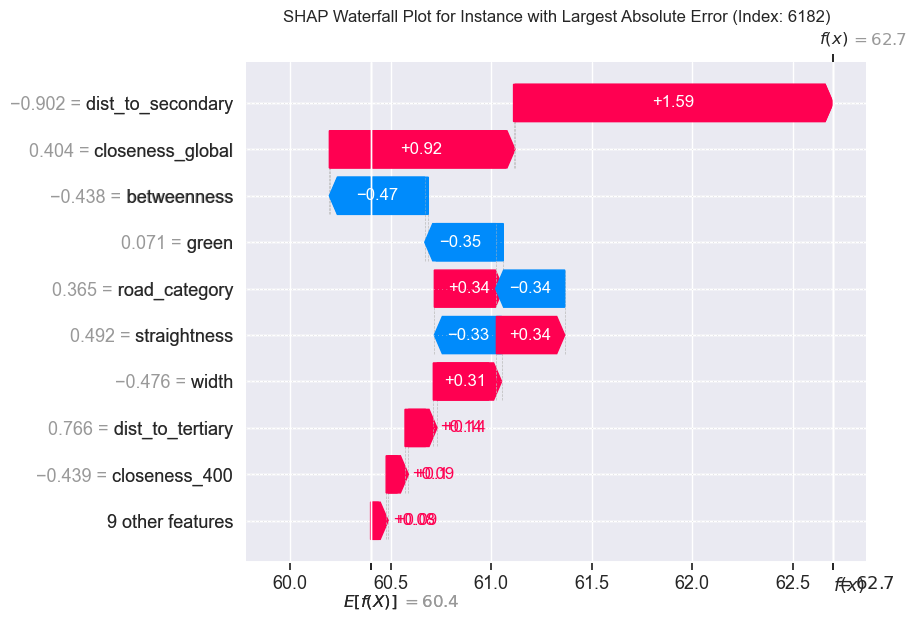

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

data_test["y_pred"]= y_pred
data_test["y_truth"]= y_test
data_test["y_diff"]= y_pred - y_test

n = 0 # 0 = largest error, 1 = second largest, etc.

# Find the index (in data_test) of the instance with the largest absolute error
idx = data_test["y_diff"].abs().sort_values(ascending=False).index[n]
pos = data_test.index.get_loc(idx)

# Compute SHAP values only for that single instance
shap_value_test = explainer.shap_values(X_test.iloc[[pos]])

# Waterfall plot for first instance
shap.plots.waterfall(shap.Explanation(values=shap_value_test[0], # SHAP values for the (only) row we computed
                                     base_values=explainer.expected_value,
                                     data=X_test.iloc[pos, :]),
                                     show=False)

plt.title(f"SHAP Waterfall Plot - Rank #{n+1} Absolute Error (Index: {idx})")
plt.show()

Force plot

What the Force Plot Shows
The base value (usually in the center) is the average model output over the background dataset — think of it as the baseline prediction before seeing any features.

The final prediction for the instance is shown at the right (or left, depending on value).

Arrows or colored bars represent feature contributions pushing the prediction up (towards higher values, often red) or down (towards lower values, often blue).

The length of each arrow corresponds to the magnitude of the feature’s impact.

Features are stacked to show cumulative effect from the base value to the prediction.



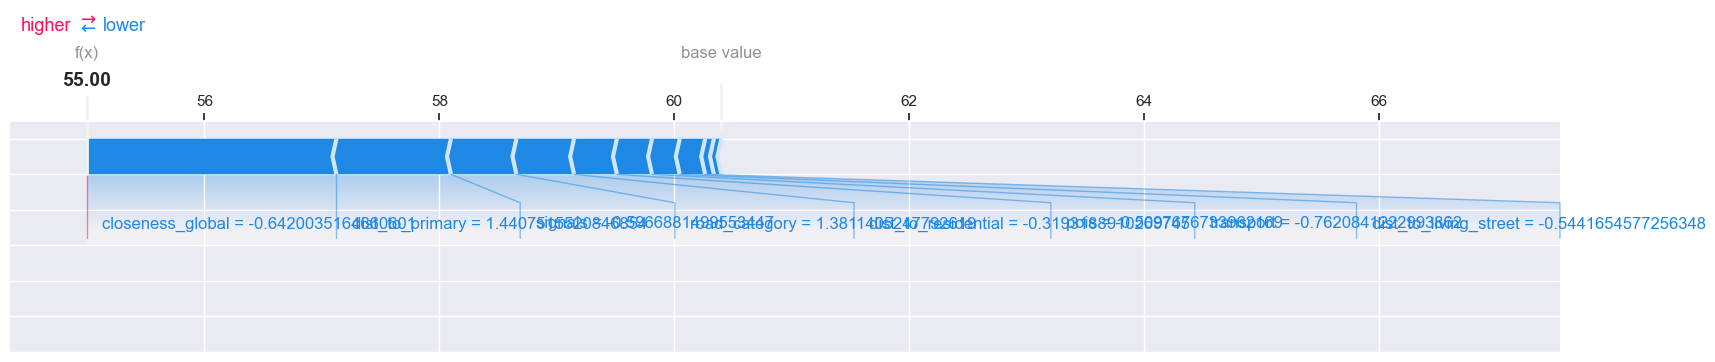

In [11]:
# Create the force plot for the first instance
shap.force_plot(
    explainer.expected_value,          # base value
    shap_values[0],                    # SHAP values for first  instance
    X_train.iloc[0, :],             # feature values for first  instance
    matplotlib=True                    # plot inline with matplotlib
)